Focus of the final project is to create a breakdown predictor to drive adaptative text design 

To start the project I will import some libraries that will help me set up a neural network, ways to read data. 

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

Next I will import data from the University of Ghent that deals with observations of people reading in english 

In [3]:
PATH = "L2ReadingData.xlsx"

df = pd.read_excel("/Users/emmamaenhout/Desktop/Channel Islands/Spring 2026/Machine Learning/mlclass/src/L2ReadingData.xlsx")

print(df.shape)
print(df.columns.tolist())
df.head()

(534154, 57)
['PP_NR', 'GROUP', 'LANGUAGE_RANK', 'LANGUAGE', 'PART', 'TRIAL', 'TRIAL_FIXATION_COUNT', 'TRIAL_TOTAL_READING_TIME', 'WORD_ID_WITHIN_TRIAL', 'WORD_ID', 'WORD', 'WORD_AVERAGE_FIX_PUPIL_SIZE', 'WORD_FIXATION_COUNT', 'WORD_FIXATION_%', 'WORD_RUN_COUNT', 'WORD_FIRST_RUN_START_TIME', 'WORD_FIRST_RUN_END_TIME', 'WORD_FIRST_RUN_FIXATION_COUNT', 'WORD_FIRST_RUN_FIXATION_%', 'WORD_GAZE_DURATION', 'WORD_SECOND_RUN_START_TIME', 'WORD_SECOND_RUN_END_TIME', 'WORD_SECOND_RUN_FIXATION_COUNT', 'WORD_SECOND_RUN_FIXATION_%', 'WORD_THIRD_RUN_START_TIME', 'WORD_THIRD_RUN_END_TIME', 'WORD_THIRD_RUN_FIXATION_COUNT', 'WORD_THIRD_RUN_FIXATION_%', 'WORD_FIRST_FIXATION_DURATION', 'WORD_FIRST_FIXATION_INDEX', 'WORD_FIRST_FIXATION_RUN_INDEX', 'WORD_FIRST_FIXATION_TIME', 'WORD_FIRST_FIXATION_VISITED_WORD_COUNT', 'WORD_FIRST_FIXATION_X', 'WORD_FIRST_FIXATION_Y', 'WORD_FIRST_FIX_PROGRESSIVE', 'WORD_SECOND_FIXATION_DURATION', 'WORD_SECOND_FIXATION_RUN', 'WORD_SECOND_FIXATION_TIME', 'WORD_SECOND_FIXATION_

,PP_NR,GROUP,LANGUAGE_RANK,LANGUAGE,PART,TRIAL,TRIAL_FIXATION_COUNT,TRIAL_TOTAL_READING_TIME,WORD_ID_WITHIN_TRIAL,WORD_ID,...,WORD_LAST_FIXATION_RUN,WORD_LAST_FIXATION_TIME,WORD_LAST_FIXATION_X,WORD_LAST_FIXATION_Y,WORD_GO_PAST_TIME,WORD_SELECTIVE_GO_PAST_TIME,WORD_TOTAL_READING_TIME,WORD_TOTAL_READING_TIME_%,WORD_SPILLOVER,WORD_SKIP
0,pp01,bilingual,L2,English,3,5,125,27561,1,3-5-1,...,1,216,146.8,97.3,330,330,330,0.012,.,0
1,pp01,bilingual,L2,English,3,5,125,27561,2,3-5-2,...,.,.,.,.,.,.,.,.,.,1
2,pp01,bilingual,L2,English,3,5,125,27561,3,3-5-3,...,1,379,191,96,177,177,177,0.0064,181,0
3,pp01,bilingual,L2,English,3,5,125,27561,4,3-5-4,...,1,575,245.2,93.9,181,181,181,0.0066,170,0
4,pp01,bilingual,L2,English,3,5,125,27561,5,3-5-5,...,1,1316,355.9,103.3,709,709,709,0.0257,379,0


Next section I want to move some of the columns over to a numeric rather than string that way I can put them all together to find the standard deviation, the mean, and the max. 

In [4]:
numeric_cols = [
    "WORD_GAZE_DURATION",
    "WORD_AVERAGE_FIX_PUPIL_SIZE",
    "WORD_SKIP",
    "WORD_TOTAL_READING_TIME",
    "WORD_FIXATION_%"
]

# If WORD_FIXATION_% contains percent signs, clean it first:
if "WORD_FIXATION_%" in df.columns:
    df["WORD_FIXATION_%"] = (
        df["WORD_FIXATION_%"].astype(str).str.replace("%", "", regex=False)
    )

for c in numeric_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

df[numeric_cols].describe()

,WORD_GAZE_DURATION,WORD_AVERAGE_FIX_PUPIL_SIZE,WORD_SKIP,WORD_TOTAL_READING_TIME,WORD_FIXATION_%
count,363740.000000,363740.000000,534154.000000,364640.000000,534154.000000
mean,256.429527,2073.142553,0.456284,313.260155,0.010117
std,142.393296,538.352686,0.498086,202.664613,0.009636
min,1.000000,375.000000,0.000000,0.000000,0.000000
25%,169.000000,1688.000000,0.000000,183.000000,0.000000
50%,224.000000,2076.000000,0.000000,258.000000,0.009500
75%,305.000000,2434.000000,1.000000,382.000000,0.014700
max,3376.000000,4909.000000,1.000000,4612.000000,0.150000


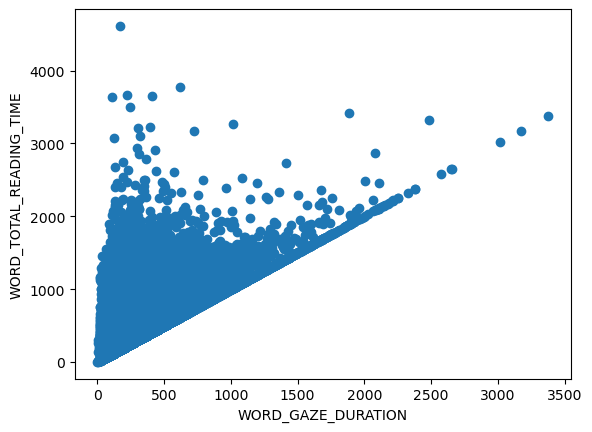

In [5]:
plt.figure()
plt.scatter(df["WORD_GAZE_DURATION"], df["WORD_TOTAL_READING_TIME"])
plt.xlabel("WORD_GAZE_DURATION")
plt.ylabel("WORD_TOTAL_READING_TIME")
plt.show()

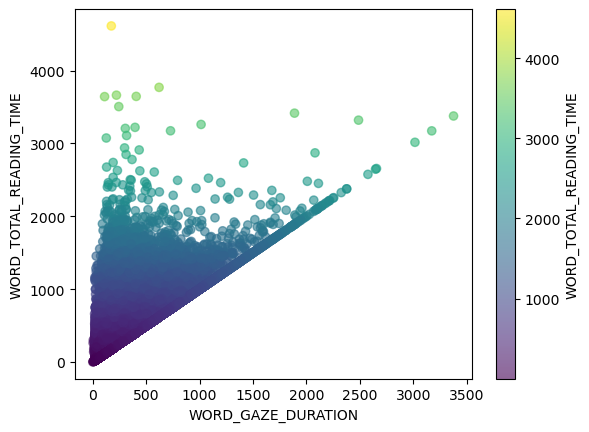

In [6]:
plt.figure()

plt.scatter(
    df["WORD_GAZE_DURATION"],
    df["WORD_TOTAL_READING_TIME"],
    c=df["WORD_TOTAL_READING_TIME"],
    cmap="viridis",
    alpha=0.6
)

plt.colorbar(label="WORD_TOTAL_READING_TIME")

plt.xlabel("WORD_GAZE_DURATION")
plt.ylabel("WORD_TOTAL_READING_TIME")

plt.show()

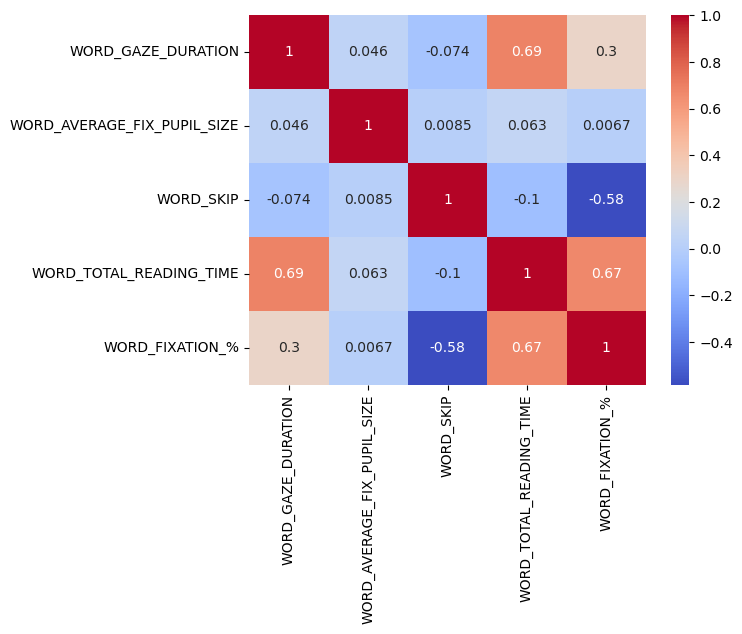

In [7]:
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm")
plt.show()

When looking at the data presented, I also want to see for a sentence lenght to understand the syntax to distinguish between syntaxtic and lexical difficulty. For this I also need to make a strong distinguishing to make differences between alphabetical, numerical, and punctuation. As each can bring forth it's own challenge. 

In [8]:
# Adjust word column 
WORD_COL = "WORD"

df[WORD_COL] = df[WORD_COL].astype(str)

# break apart the punctuation, wordlenght, and to see if it is a number
df["word_len"] = df[WORD_COL].str.len()
df["is_punct"] = df[WORD_COL].str.fullmatch(r"\W+").fillna(False).astype(int)
df["is_number"] = df[WORD_COL].str.fullmatch(r"\d+").fillna(False).astype(int)

#print how it looks 
df[["word_len", "is_punct", "is_number"]].head()

,word_len,is_punct,is_number
0,6,0,0
1,4,0,0
2,2,0,0
3,9,0,0
4,10,0,0


Frm here I would need to implement the z-score on the numeric column to account for differences Z = (raw score - mean) / Standard deviation

In [9]:
group_cols = ["PP_NR", "TRIAL"]

agg_dict = {
    # gaze
    "WORD_GAZE_DURATION": ["mean", "std", "max"],
    "WORD_AVERAGE_FIX_PUPIL_SIZE": ["mean", "std"],
    "WORD_TOTAL_READING_TIME": ["sum", "mean", "max"],

    # skipping/fixation
    "WORD_SKIP": ["mean"],
    "WORD_FIXATION_%": ["mean"],

    # text features aggregated
    "word_len": ["mean", "std", "max"],
    "is_punct": ["mean"],
    "is_number": ["mean"],
    
    # counts (how many word rows in trial)
    WORD_COL: ["count"],
}

trial_level = df.groupby(group_cols).agg(agg_dict).reset_index()
trial_level.columns = [
    f"{a}_{b}" if b else a
    for a, b in trial_level.columns.to_flat_index()
]

trial_level.rename(columns={f"{WORD_COL}_count": "n_words_in_trial"}, inplace=True)

print(trial_level.shape)
trial_level.head()

(2840, 18)


,PP_NR,TRIAL,WORD_GAZE_DURATION_mean,WORD_GAZE_DURATION_std,WORD_GAZE_DURATION_max,WORD_AVERAGE_FIX_PUPIL_SIZE_mean,WORD_AVERAGE_FIX_PUPIL_SIZE_std,WORD_TOTAL_READING_TIME_sum,WORD_TOTAL_READING_TIME_mean,WORD_TOTAL_READING_TIME_max,WORD_SKIP_mean,WORD_FIXATION_%_mean,word_len_mean,word_len_std,word_len_max,is_punct_mean,is_number_mean,n_words_in_trial
0,pp01,5,283.583333,166.311870,989.0,2580.544295,289.771125,52816.0,338.564103,1051.0,0.344828,0.009709,5.064039,2.560329,13,0.0,0.0,203
1,pp01,6,255.069307,119.273489,605.0,2543.439802,216.394956,29742.0,294.475248,916.0,0.343284,0.014131,5.328358,2.790360,13,0.0,0.0,134
2,pp01,7,256.327381,118.122564,871.0,2416.629405,267.649044,52992.0,315.428571,871.0,0.354545,0.008825,5.022727,2.416540,16,0.0,0.0,220
3,pp01,8,267.442857,120.501725,853.0,2506.509000,287.606467,43175.0,308.392857,853.0,0.333333,0.010511,4.978495,2.644642,14,0.0,0.0,186
4,pp01,9,252.522293,119.468781,689.0,2477.994713,283.528620,48137.0,306.605096,945.0,0.359223,0.009703,4.898058,2.505466,14,0.0,0.0,206


In [10]:
def zscore_within_group(s):
    mu = s.mean()
    sd = s.std(ddof=0)
    if sd == 0 or np.isnan(sd):
        return (s - mu)  
    return (s - mu) / sd


norm_cols = [
    "WORD_TOTAL_READING_TIME_sum",
    "WORD_GAZE_DURATION_mean",
    "WORD_GAZE_DURATION_max",
    "WORD_AVERAGE_FIX_PUPIL_SIZE_mean",
]

In [11]:
for c in norm_cols:
    if c in trial_level.columns:
        trial_level[c + "_z"] = trial_level.groupby("PP_NR")[c].transform(zscore_within_group)

trial_level[[c + "_z" for c in norm_cols if c in trial_level.columns]].describe()

,WORD_TOTAL_READING_TIME_sum_z,WORD_GAZE_DURATION_mean_z,WORD_GAZE_DURATION_max_z,WORD_AVERAGE_FIX_PUPIL_SIZE_mean_z
count,2.840000e+03,2.840000e+03,2.840000e+03,2.840000e+03
mean,-1.000764e-17,3.052331e-16,-3.440128e-17,6.379873e-17
std,1.000176e+00,1.000176e+00,1.000176e+00,1.000176e+00
min,-4.063394e+00,-2.830770e+00,-1.738324e+00,-3.448288e+00
25%,-5.351822e-01,-6.867607e-01,-6.685193e-01,-6.688249e-01
50%,2.292179e-02,-7.423453e-02,-2.190839e-01,-5.298907e-02
75%,6.140556e-01,6.065578e-01,4.002292e-01,5.925236e-01
max,4.181162e+00,4.048970e+00,8.709668e+00,4.588139e+00


In [14]:
trial_level["breakdown"] = (
    (trial_level["WORD_TOTAL_READING_TIME_sum_z"] > 2.0) |
    (trial_level["WORD_GAZE_DURATION_max_z"] > 2.0)
).astype(int)

trial_level["breakdown"].value_counts(normalize=True)

breakdown
0    0.94331
1    0.05669
Name: proportion, dtype: float64

In [15]:
y = trial_level["breakdown"].astype(int)

# Drop IDs and raw target-ish columns you don’t want leaked
drop_cols = ["breakdown", "PP_NR", "TRIAL"]
X = trial_level.drop(columns=[c for c in drop_cols if c in trial_level.columns])

# Keep only numeric columns
X = X.select_dtypes(include=[np.number]).copy()

print(X.shape, y.shape)

(2840, 20) (2840,)


In [16]:
y = trial_level['breakdown']

In [17]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [19]:
groups = trial_level["PP_NR"]

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

In [20]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [41]:
'''device = "cuda" if torch.cuda.is_available() else "cpu"

Xtr = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
ytr = torch.tensor(y_train.values.reshape(-1, 1), dtype=torch.float32).to(device)

Xte = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)
yte = torch.tensor(y_test.values.reshape(-1, 1), dtype=torch.float32).to(device)

train_loader = DataLoader(
    TensorDataset(Xtr, ytr),
    batch_size=64,
    shuffle=True
)

class MLP(nn.Module):
    def __init__(self, d_in):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_in, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.net(x)

model = MLP(X_train_scaled.shape[1]).to(device)'''

In [43]:
'''# Use BCEWithLogitsLoss (more numerically stable than Sigmoid + BCELoss)
pos_weight = torch.tensor([(len(y_train)-y_train.sum()) / max(y_train.sum(), 1)], dtype=torch.float32).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

opt = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(50):
    model.train()
    total_loss = 0
    for xb, yb in train_loader:
        opt.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        opt.step()
        total_loss += loss.item()
    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1:02d} | loss={total_loss/len(train_loader):.4f}")

model.eval()
with torch.no_grad():
    logits = model(Xte).cpu().numpy().reshape(-1)
    proba_mlp = 1 / (1 + np.exp(-logits))

print("MLP AUC:", roc_auc_score(y_test, proba_mlp))'''

Epoch 05 | loss=0.0491
Epoch 10 | loss=0.0586
Epoch 15 | loss=0.0379
Epoch 20 | loss=0.0361
Epoch 25 | loss=0.0429
Epoch 30 | loss=0.0366
Epoch 35 | loss=0.0325
Epoch 40 | loss=0.0359
Epoch 45 | loss=0.0490
Epoch 50 | loss=0.0410
MLP AUC: 0.9674255330132673


/var/folders/5h/vhxcqvpj4jb5kdfz5yfnc6f40000gn/T/ipykernel_36784/2535863255.py:23: RuntimeWarning: overflow encountered in exp
  proba_mlp = 1 / (1 + np.exp(-logits))


In [27]:

from sklearn.metrics import roc_auc_score

# Assuming X_train_scaled, X_test_scaled, y_train, and y_test are already defined 
# from your previous preprocessing steps in the notebook.

device = "cuda" if torch.cuda.is_available() else "cpu"

# 1. DATA PREPARATION: Create Sequences for LSTM
# This "sliding window" allows the model to see patterns in movement/difficulty over time.
def create_sequences(data, target, seq_length=5):
    sequences = []
    labels = []
    for i in range(len(data) - seq_length):
        sequences.append(data[i:i+seq_length])
        labels.append(target[i+seq_length])
    return np.array(sequences), np.array(labels)

# LSTM-specific data (3D: Batch, Sequence, Features)
X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train.values)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test.values)

Xtr_lstm = torch.tensor(X_train_seq, dtype=torch.float32).to(device)
ytr_lstm = torch.tensor(y_train_seq.reshape(-1, 1), dtype=torch.float32).to(device)
Xte_lstm = torch.tensor(X_test_seq, dtype=torch.float32).to(device)

lstm_loader = DataLoader(TensorDataset(Xtr_lstm, ytr_lstm), batch_size=64, shuffle=True)

# MLP-specific data (2D: Batch, Features) 
Xtr_mlp = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
ytr_mlp = torch.tensor(y_train.values.reshape(-1, 1), dtype=torch.float32).to(device)
Xte_mlp = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)

mlp_loader = DataLoader(TensorDataset(Xtr_mlp, ytr_mlp), batch_size=64, shuffle=True)

# 2. MODEL DEFINITIONS
class MLP(nn.Module):
    def __init__(self, d_in):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_in, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.net(x)

class BreakdownLSTM(nn.Module):
    def __init__(self, d_in, hidden_dim=64, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(d_in, hidden_dim, num_layers, batch_first=True, dropout=0.2)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        # Use the output from the last time step in the sequence
        return self.classifier(lstm_out[:, -1, :])

# 3. TRAINING SETUP
# Calculate pos_weight to handle the rarity of breakdown events.
pos_weight = torch.tensor([(len(y_train)-y_train.sum()) / max(y_train.sum(), 1)], dtype=torch.float32).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

def train_engine(model, loader, epochs=50):
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for xb, yb in loader:
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        if (epoch+1) % 10 == 0:
            print(f"Epoch {epoch+1:02d} | loss={total_loss/len(loader):.4f}")

# 4. EXECUTION
print("--- Training MLP ---")
mlp_model = MLP(X_train_scaled.shape[1]).to(device)
train_engine(mlp_model, mlp_loader)

print("\n--- Training LSTM ---")
# d_in matches the features tracked in your gaze and text files[cite: 1, 2].
lstm_model = BreakdownLSTM(d_in=X_train_scaled.shape[1]).to(device)
train_engine(lstm_model, lstm_loader)

# 5. EVALUATION
print("\n--- Final Results ---")
mlp_model.eval()
lstm_model.eval()

with torch.no_grad():
    # MLP AUC
    mlp_logits = mlp_model(Xte_mlp).cpu().squeeze()
    proba_mlp = torch.sigmoid(mlp_logits)
    print("MLP AUC:", roc_auc_score(y_test, proba_mlp.tolist()))

    # LSTM AUC
    lstm_logits = lstm_model(Xte_lstm).cpu().squeeze()
    proba_lstm = torch.sigmoid(lstm_logits)
    print("LSTM AUC:", roc_auc_score(y_test_seq, proba_lstm.tolist()))

--- Training MLP ---
Epoch 10 | loss=0.2066
Epoch 20 | loss=0.1206
Epoch 30 | loss=0.0990
Epoch 40 | loss=0.0662
Epoch 50 | loss=0.0493

--- Training LSTM ---
Epoch 10 | loss=1.0048
Epoch 20 | loss=0.7285
Epoch 30 | loss=0.3744
Epoch 40 | loss=0.2080
Epoch 50 | loss=0.1449

--- Final Results ---
MLP AUC: 0.9724846419906046
LSTM AUC: 0.6044465271269395
